In [2]:
import polars as pl

In [12]:
lf = pl.scan_csv("./data/L2_options_*.csv")
nvda = lf.filter(pl.col("UnderlyingSymbol") == "NVDA")
nvda = nvda.drop(["AKA", "OptionSymbol", 'Exchange'])
nvda = nvda.collect()

In [ ]:
ivs = nvda.select([pl.col("Expiration"), pl.col("DataDate"), pl.col("IV")])
ivs = ivs.with_columns(pl.col("Expiration").str.to_date(format="%m/%d/%Y"), pl.col("DataDate"), pl.col("IV"))
ivs_grouped = ivs.group_by(pl.col("Expiration"))
iv_30d_mean = ivs_grouped.mean().sort("Expiration")         
iv_30d_med = ivs_grouped.median().sort("Expiration")        
display(iv_30d_mean)
display(iv_30d_med)

In [25]:
optstats = pl.scan_csv("./data/L2_optionstats_*.csv")
nvda = optstats.filter(pl.col("symbol") == "NVDA")
nvda = nvda.drop(["callvol", "putvol", "totalvol", "calloi", "putoi", "comment"])
nvda = nvda.collect()

In [35]:
iv30call = nvda.with_columns([pl.col("quotedate").str.to_date(format="%m/%d/%Y"), pl.col("iv30call")]).select([pl.col("quotedate"), pl.col("iv30call")])
iv30put = nvda.with_columns([pl.col("quotedate").str.to_date(format="%m/%d/%Y"), pl.col("iv30put")]).select([pl.col("quotedate"), pl.col("iv30put")])

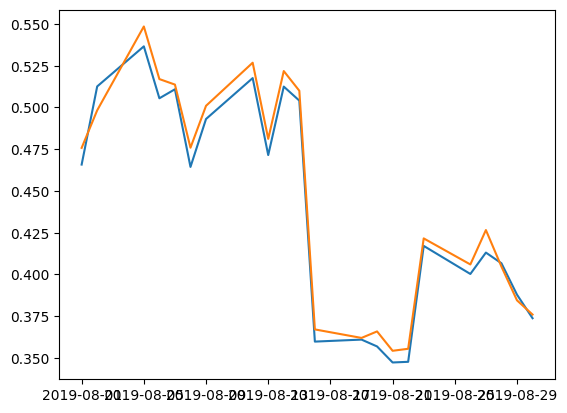

In [36]:
import matplotlib.pyplot as plt
plt.plot(iv30call["quotedate"], iv30call["iv30call"])
plt.plot(iv30put["quotedate"], iv30put["iv30put"])
plt.show()

In [41]:
lf =pl.scan_csv("./data/L2_options_*.csv")
nvda = lf.filter(pl.col("UnderlyingSymbol") == "NVDA")
nvda = nvda.select([pl.col("DataDate").str.to_date(format="%m/%d/%Y"), pl.col("UnderlyingPrice")])
nvda = nvda.unique().sort("DataDate").collect()
display(nvda)

DataDate,UnderlyingPrice
date,f64
2019-08-01,164.92
2019-08-02,161.19
2019-08-05,150.79
2019-08-06,152.35
2019-08-07,153.89
…,…
2019-08-26,165.45
2019-08-27,161.8
2019-08-28,161.22


In [ ]:
c2c_vol = nvda.with_columns(pl.col("DataDate").alias("Date"), pl.col("UnderlyingPrice").alias("Price"), pl.col("UnderlyingPrice").diff().alias("diff"))
c2c_vol = c2c_vol.

DataDate,UnderlyingPrice,Date,Price,Vol
date,f64,date,f64,f64
2019-08-01,164.92,2019-08-01,164.92,null
2019-08-02,161.19,2019-08-02,161.19,-3.73
2019-08-05,150.79,2019-08-05,150.79,-10.4
2019-08-06,152.35,2019-08-06,152.35,1.56
2019-08-07,153.89,2019-08-07,153.89,1.54
…,…,…,…,…
2019-08-26,165.45,2019-08-26,165.45,3.01
2019-08-27,161.8,2019-08-27,161.8,-3.65
2019-08-28,161.22,2019-08-28,161.22,-0.58
